In [1]:
# Import Libraries, and Load and Explore Dataset

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Basic exploration
print("Feature names:", wine.feature_names)
print("Number of samples:", X.shape[0])
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Number of samples: 178
Class distribution: {0: 59, 1: 71, 2: 48}


In [2]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 142
Testing set size: 36


In [3]:
# KNN Classification

k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f"k = {k}  Accuracy = {acc:.4f}")

k = 1  Accuracy = 0.7778
k = 5  Accuracy = 0.8056
k = 11  Accuracy = 0.8056
k = 15  Accuracy = 0.8056
k = 21  Accuracy = 0.8056


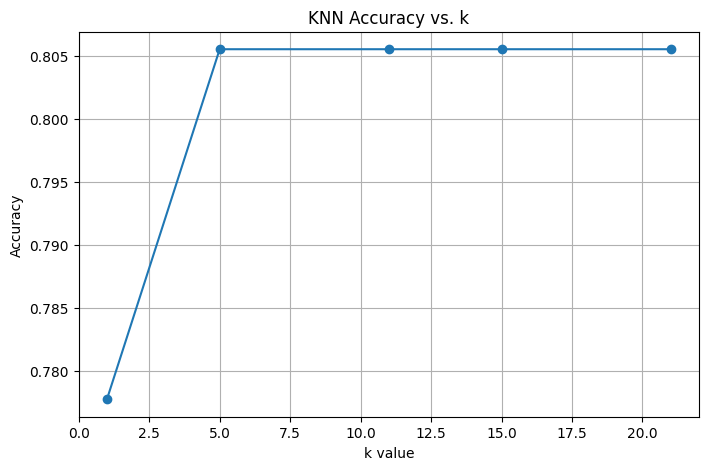

In [4]:
# Plot KNN Accuracy Trends

plt.figure(figsize=(8,5))
plt.plot(k_values, knn_accuracies, marker='o')
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs. k")
plt.grid(True)
plt.show()

In [5]:
# RNN Classification

radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for radius in radius_values:
    rnn = RadiusNeighborsClassifier(radius=radius, outlier_label=1)
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    print(f"Radius = {radius}  Accuracy = {acc:.4f}")

Radius = 350  Accuracy = 0.7222
Radius = 400  Accuracy = 0.6944
Radius = 450  Accuracy = 0.6944
Radius = 500  Accuracy = 0.6944
Radius = 550  Accuracy = 0.6667
Radius = 600  Accuracy = 0.6667


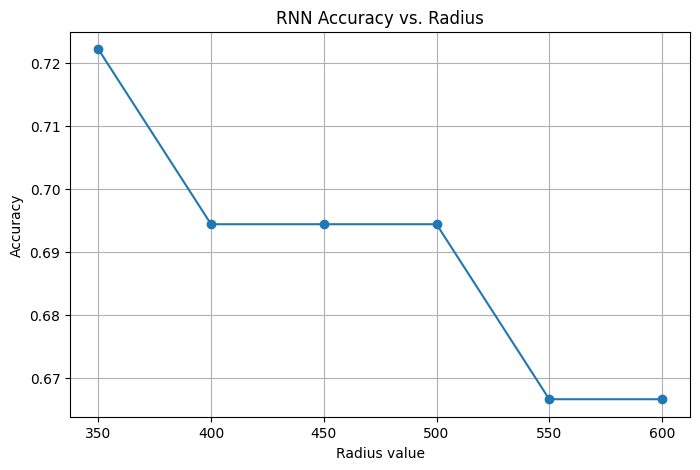

In [6]:
# Plot RNN Accuracy Trends

plt.figure(figsize=(8,5))
plt.plot(radius_values, rnn_accuracies, marker='o')
plt.xlabel("Radius value")
plt.ylabel("Accuracy")
plt.title("RNN Accuracy vs. Radius")
plt.grid(True)
plt.show()

In [7]:
# Summary Comparison

print("KNN Accuracies:")
for k, acc in zip(k_values, knn_accuracies):
    print(f"  k={k}: {acc:.4f}")

print("\nRNN Accuracies:")
for r, acc in zip(radius_values, rnn_accuracies):
    print(f"  radius={r}: {acc:.4f}")

KNN Accuracies:
  k=1: 0.7778
  k=5: 0.8056
  k=11: 0.8056
  k=15: 0.8056
  k=21: 0.8056

RNN Accuracies:
  radius=350: 0.7222
  radius=400: 0.6944
  radius=450: 0.6944
  radius=500: 0.6944
  radius=550: 0.6667
  radius=600: 0.6667
